# Step 1: Data Exploration & Cleaning

For the Tardis project , we will need some libraries

In [162]:
import pandas as pd  # panda for open a csv and extract the data for file and data manipulation
import matplotlib.pyplot as pl  # matplotlib to create visualisation via graphs
import numpy as np  # numpy for fast calcul for graph

This are some macros to change the way the code is 

In [163]:
# this is the filename use for the analisys
DATASET = "dataset.csv"

# this the list of the columns name that have to be transform to numeric
COLUMNS_TO_NUMERIC = [
    "Average journey time",
    "Number of scheduled trains",
    "Number of cancelled trains",
    "Number of trains delayed at departure",
    "Average delay of late trains at departure",
    "Average delay of all trains at departure",
    "Number of trains delayed at arrival",
    "Average delay of late trains at arrival",
    "Average delay of all trains at arrival",
    "Number of trains delayed > 15min",
    "Average delay of trains > 15min (if competing with flights)",
    "Number of trains delayed > 30min",
    "Number of trains delayed > 60min",
    "Pct delay due to external causes",
    "Pct delay due to infrastructure",
    "Pct delay due to traffic management",
    "Pct delay due to rolling stock",
    "Pct delay due to station management and equipment reuse",
    "Pct delay due to passenger handling (crowding, disabled persons, connections)",
]

## Open the dataset and clean it

Open the file and save the dataframe

In [164]:
raw_df = pd.read_csv(DATASET, on_bad_lines="skip", sep=";")

And this is a tab representation of the file

In [165]:
raw_df

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870,5.0,NaN,289.0,11.24780854,...,110.0,6.51,44.0,8.0,36.13445378,31.09243697,10.92436975,15.96638655,"5,04",0.840336134
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,NaN,213.0,8.479968701,...,32.0,5.363539095,9.0,4.0,20.0,35.0,16.66666667,16.66666667,8.333333333,3.333333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,NaN,21.0,6.23968254,...,11.0,2.938053097,6.0,1.0,22.22222222,27.77777778,16.66666667,16.66666667,5.555555556,11.11111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211268,...,39.0,5.292211221,18.0,NaN,33.33333333,22.22222222,16.66666667,20.37037037,5.555555556,1.851851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.0,472.0,4.0,NaN,224.0,6.784672619,...,42.0,4.882371795,10.0,0.0,15.78947368,45.61403509,NaN,15.78947368,1.754385965,1.754385965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12065,2020-09,National,LE CREUSOT MONTCEAU MONTCHANIN,PARIS LYON,84.0,214.0,2.0,NaN,164.0,NaN,...,10.0,41.27037037,6.0,NaN,18.18181818,22.727,40.90909091,0.0,NaN,4.545454545
12066,2024-05,National,BORDEAUX ST JEAN,TOURCOING,313.0,30.0,0.0,NaN,4.0,3.775,...,9.0,25.333333333,3.0,0.0,0.0,44.444444440000005,22.22%,11.11111111,11.11111111,11.11111111
12067,2018-08,National,PARIS MONTPARNASSE,ST PIERRE DES CORPS,67.0,358.0,2.0,NaN,53.0,8.623584906,...,13.0,3.636938202,5.0,3.0,12.19512195,24.3902439,24.3902439,31.70731707,4.87804878,2.43902439
12068,2018-03,National,PARIS LYON,ANNECY,226.0,196.0,5.0,NaN,30.0,17.57333333,...,32.0,9.188481675,11.0,5.0,20.68965517,NaN,31.03448276,24.13793103,0.0,0.0


## Let's clean our dataframe

We choose to remove the whole row if there are duplicates only and keep the line with empty cell.

Now we remove duplicate rows

In [166]:
df = raw_df.drop_duplicates(
    ignore_index=True
)  # df is the result of the action of removing rows
# ignore_index=True is a parameter that permit to give new index to the df's rows, without it the new rows will keep their old index

The duplicates rows are now removed. For the empty cell we choose to fill them depending of the other values. But first we need to transform some columns into numeric values.

In [167]:
for col in (
    COLUMNS_TO_NUMERIC
):  # COLUMNS_TO_NUMERIC is a list of the columns we have to change
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", "."), errors="coerce"
    )  # we transform "str" value to numeric
# and we replace the dot by coma for decimal values

We can change the format for the date

In [168]:
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m", errors="coerce").dt.to_period(
    "M"
)
# the function above transform the "str" value to a time value as we figured out that the format used in the file was year-month
# so we are keeping the year and the month only and if the value can't be tranform "Nat" will be display instead

## Fill the gap

Now we transform our values in a type we want, we can use the values to fill empty cell. We need to fill the empty numercial values. We have the choice between three function: ffill , bfill and interpolate.

### What function to use?

"ffill" function will take the forward value and copy paste it to the empty cells.
By the same principle "bfill" function will take the backward value and copy paste it to the empty cells.
Fortunatly there is the "interpolate" function that will do calculation and give us a value depending of the other values of the dataframe. 
This is not perfect, but it's far better that simply copy pasting a neighbour value.

In [169]:
df[COLUMNS_TO_NUMERIC] = df[COLUMNS_TO_NUMERIC].interpolate()
df

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,NaN,289.0,11.247809,...,110.0,6.510000,44.0,8.0,36.134454,31.092437,10.924370,15.966387,5.040000,0.840336
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,NaN,213.0,8.479969,...,32.0,5.363539,9.0,4.0,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,NaN,21.0,6.239683,...,11.0,2.938053,6.0,1.0,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211,...,39.0,5.292211,18.0,0.5,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,NaN,224.0,6.784673,...,42.0,4.882372,10.0,0.0,15.789474,45.614035,8.333333,15.789474,1.754386,1.754386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11891,NaT,National,SAINT ETIENNE CHATEAUCREUX,PARIS LYON,168.00,113.0,1.0,NaN,19.0,5.662281,...,14.0,5.510417,5.0,2.0,21.052632,36.842105,5.263158,21.052632,10.526316,5.263158
11892,NaT,NaN,PARIS MONTPARNASSE,NANTES,138.00,470.0,29.0,NaN,48.0,4.225694,...,6.0,31.452778,3.0,0.0,22.222222,0.000000,11.111111,33.333333,0.000000,33.333333
11893,2018-03,NaN,PERPIGNAN,PARIS LYON,305.00,163.0,1.0,NaN,63.0,8.189418,...,23.0,8.470885,14.0,7.0,57.142857,14.285714,14.285714,14.285714,0.000000,0.000000
11894,NaT,National,NICE VILLE,PARIS LYON,357.00,159.0,4.0,NaN,32.0,6.806250,...,33.0,9.321935,13.0,5.0,18.181818,36.363636,24.242424,12.121212,9.090909,0.000000


# Graph

## First Graph

Now we transform this big data into beautifull graph for a good view data

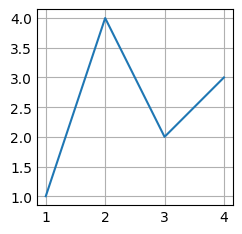

In [170]:
fig, ax = pl.subplots()  # Create a figure containing a single Axes.
ax.plot([1, 2, 3, 4], [1, 4, 2, 3])  # Plot some data on the Axes.
pl.show()

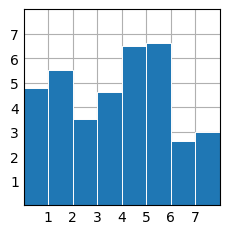

In [171]:
pl.style.use("_mpl-gallery")

# make data:
x = 0.5 + np.arange(8)
y = [4.8, 5.5, 3.5, 4.6, 6.5, 6.6, 2.6, 3.0]

# plot
fig, ax = pl.subplots()

ax.bar(x, y, width=1, edgecolor="white", linewidth=0.7)

ax.set(xlim=(0, 8), xticks=np.arange(1, 8), ylim=(0, 8), yticks=np.arange(1, 8))

pl.show()

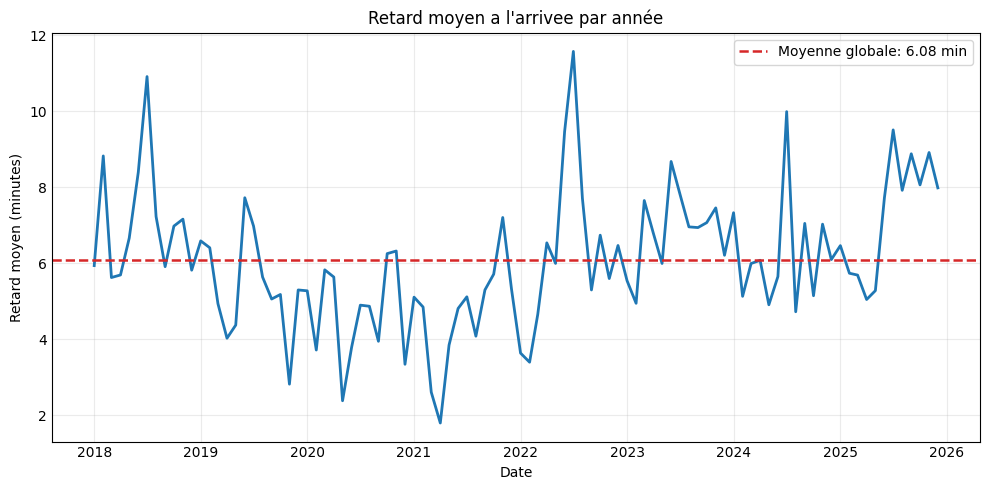

In [172]:
# Graphique: retard moyen mensuel (arrivee)
delay_col = "Average delay of all trains at arrival"

monthly_delay = (
    df[["Date", delay_col]]
    .dropna()
    .sort_values("Date")
    .groupby("Date", as_index=False)[delay_col]
    .mean()
)

fig, ax = pl.subplots(figsize=(10, 5))
ax.plot(
    monthly_delay["Date"].dt.to_timestamp(),
    monthly_delay[delay_col],
    color="tab:blue",
    linewidth=2,
)

mean_delay = monthly_delay[delay_col].mean()
ax.axhline(
    mean_delay,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
    label=f"Moyenne globale: {mean_delay:.2f} min",
)

ax.set_title("Retard moyen a l'arrivee par année")
ax.set_xlabel("Date")
ax.set_ylabel("Retard moyen (minutes)")
ax.legend()
ax.grid(alpha=0.25)
pl.tight_layout()
pl.show()

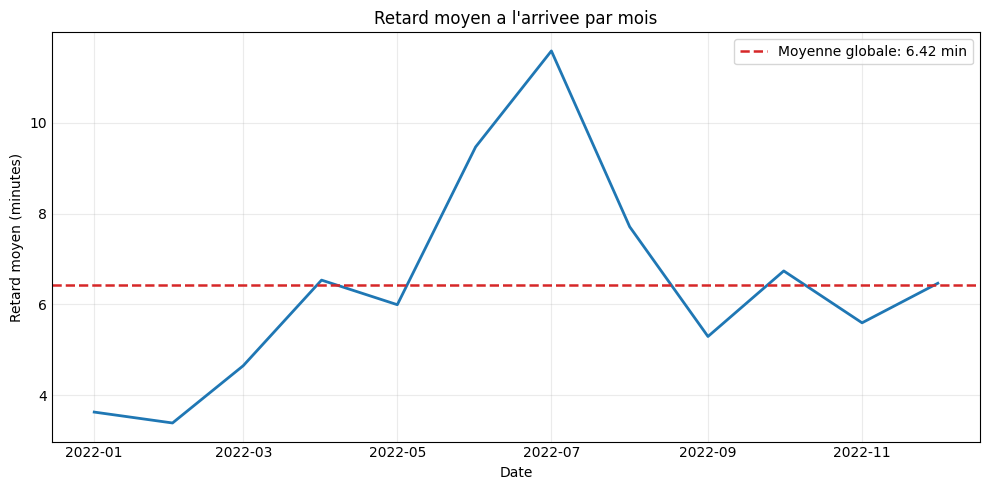

In [173]:
delay_col = "Average delay of all trains at arrival"
years = 2022

monthly_delay = (
    df.loc[df["Date"].dt.year == years, ["Date", delay_col]]
    .dropna()
    .sort_values("Date")
    .groupby("Date", as_index=False)[delay_col]
    .mean()
)

fig, ax = pl.subplots(figsize=(10, 5))
ax.plot(
    monthly_delay["Date"].dt.to_timestamp(),
    monthly_delay[delay_col],
    color="tab:blue",
    linewidth=2,
)

mean_delay = monthly_delay[delay_col].mean()
ax.axhline(
    mean_delay,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
    label=f"Moyenne globale: {mean_delay:.2f} min",
)

ax.set_title("Retard moyen a l'arrivee par mois")
ax.set_xlabel("Date")
ax.set_ylabel("Retard moyen (minutes)")
ax.legend()
ax.grid(alpha=0.25)
pl.tight_layout()
pl.show()

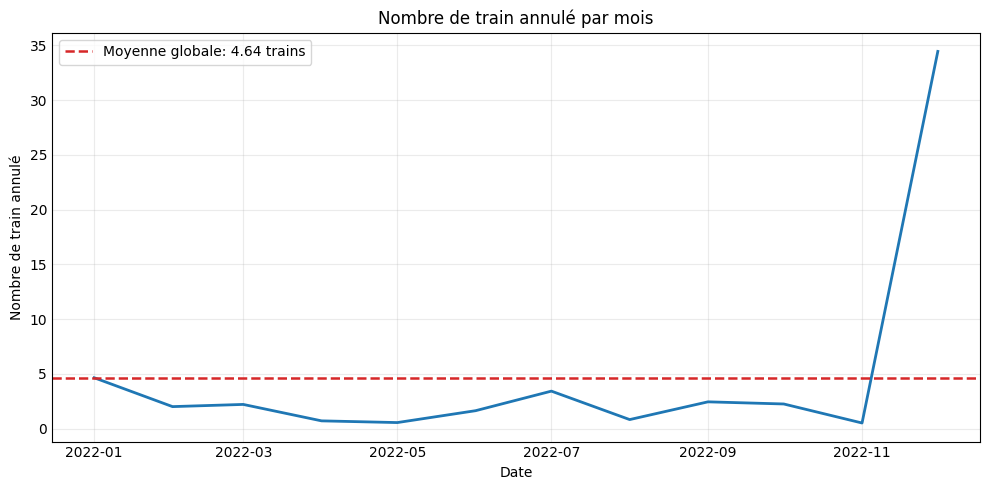

In [174]:
delay_col = "Number of cancelled trains"
years = 2022  # Année cible

monthly_delay = (
    df.loc[df["Date"].dt.year == years, ["Date", delay_col]]
    .dropna()
    .sort_values("Date")
    .groupby("Date", as_index=False)[delay_col]
    .mean()
)

fig, ax = pl.subplots(figsize=(10, 5))
ax.plot(
    monthly_delay["Date"].dt.to_timestamp(),
    monthly_delay[delay_col],
    color="tab:blue",
    linewidth=2,
)

mean_delay = monthly_delay[delay_col].mean()
ax.axhline(
    mean_delay,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
    label=f"Moyenne globale: {mean_delay:.2f} trains",
)


ax.set_title("Nombre de train annulé par mois")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre de train annulé")
ax.legend()
ax.grid(alpha=0.25)
pl.tight_layout()
pl.show()

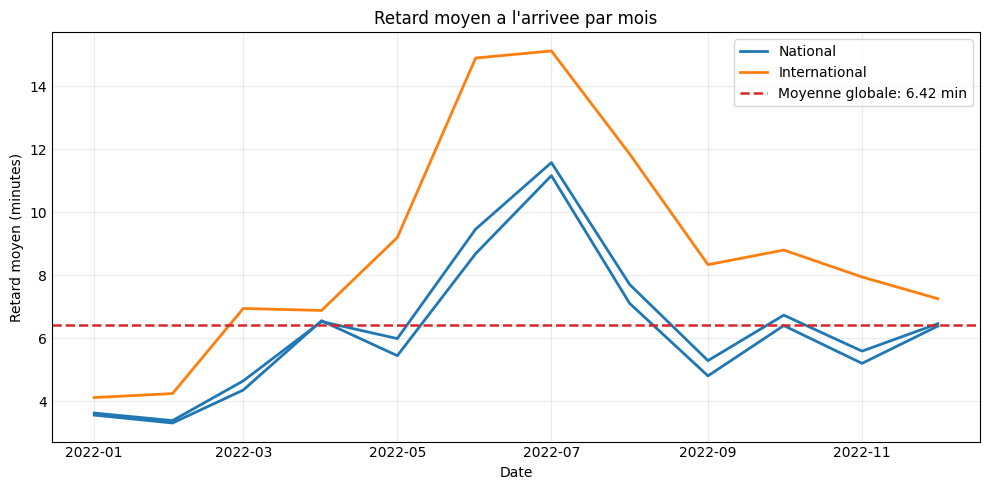

In [175]:
delay_col = "Average delay of all trains at arrival"
years = 2022

filtered = df.loc[df["Date"].dt.year == years, ["Date", "Service", delay_col]].dropna()

monthly_delay = (
    df.loc[df["Date"].dt.year == years, ["Date", delay_col]]
    .dropna()
    .sort_values("Date")
    .groupby("Date", as_index=False)[delay_col]
    .mean()
)

monthly_delay_by_service = (
    filtered.groupby(["Date", "Service"], as_index=False)[delay_col]
    .mean()
    .pivot(index="Date", columns="Service", values=delay_col)
)


fig, ax = pl.subplots(figsize=(10, 5))
ax.plot(
    monthly_delay["Date"].dt.to_timestamp(),
    monthly_delay[delay_col],
    color="tab:blue",
    linewidth=2,
)

if "National" in monthly_delay_by_service.columns:
    ax.plot(
        monthly_delay_by_service.index.to_timestamp(),
        monthly_delay_by_service["National"],
        label="National",
        color="tab:blue",
        linewidth=2,
    )

if "International" in monthly_delay_by_service.columns:
    ax.plot(
        monthly_delay_by_service.index.to_timestamp(),
        monthly_delay_by_service["International"],
        label="International",
        color="tab:orange",
        linewidth=2,
    )

mean_delay = monthly_delay[delay_col].mean()
ax.axhline(
    mean_delay,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
    label=f"Moyenne globale: {mean_delay:.2f} min",
)

ax.set_title("Retard moyen a l'arrivee par mois")
ax.set_xlabel("Date")
ax.set_ylabel("Retard moyen (minutes)")
ax.legend()
ax.grid(alpha=0.25)
pl.tight_layout()
pl.show()

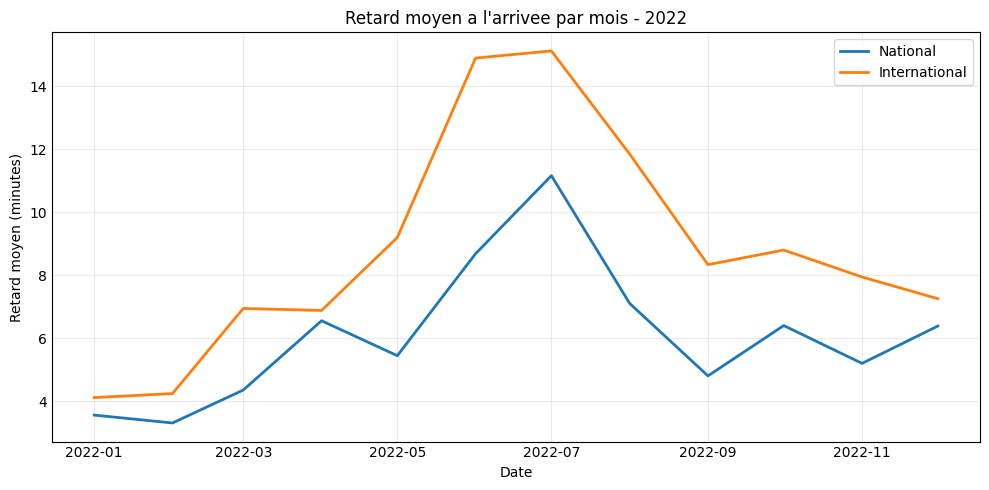

In [176]:
delay_col = "Average delay of all trains at arrival"
year = 2022

filtered = df.loc[df["Date"].dt.year == year, ["Date", "Service", delay_col]].dropna()

monthly_delay_by_service = (
    filtered.groupby(["Date", "Service"], as_index=False)[delay_col]
    .mean()
    .pivot(index="Date", columns="Service", values=delay_col)
)

fig, ax = pl.subplots(figsize=(10, 5))

if "National" in monthly_delay_by_service.columns:
    ax.plot(
        monthly_delay_by_service.index.to_timestamp(),
        monthly_delay_by_service["National"],
        label="National",
        color="tab:blue",
        linewidth=2,
    )

if "International" in monthly_delay_by_service.columns:
    ax.plot(
        monthly_delay_by_service.index.to_timestamp(),
        monthly_delay_by_service["International"],
        label="International",
        color="tab:orange",
        linewidth=2,
    )

ax.set_title(f"Retard moyen a l'arrivee par mois - {year}")
ax.set_xlabel("Date")
ax.set_ylabel("Retard moyen (minutes)")
ax.legend()
ax.grid(alpha=0.25)
pl.tight_layout()
pl.show()

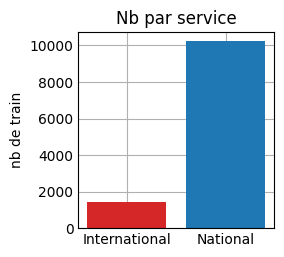

In [177]:
fig, ax = pl.subplots()


sete = df["Service"].value_counts()

fruits = ["International", "National"]
counts = [sete.International, sete.National]
bar_colors = ["tab:red", "tab:blue"]

ax.bar(fruits, counts, color=bar_colors)

ax.set_ylabel("nb de train")
ax.set_title("Nb par service")

pl.show()

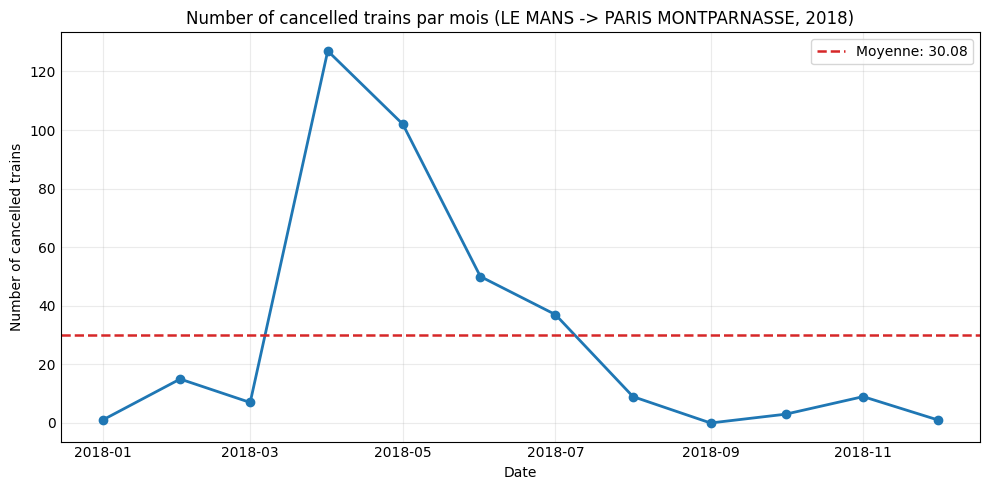

In [178]:
departure_station = "LE MANS"
arrival_station = "PARIS MONTPARNASSE"
departure_col = "Departure station"
arrival_col = "Arrival station"
target_col = "Number of cancelled trains"
year = 2018

route_monthly = (
    df.loc[
        (df["Date"].dt.year == year)
        & (df[departure_col] == departure_station)
        & (df[arrival_col] == arrival_station),
        ["Date", target_col],
    ]
    .dropna()
    .groupby("Date", as_index=False)[target_col]
    .mean()
    .sort_values("Date")
)

if route_monthly.empty:
    print(f"Aucune donnee pour {departure_station} -> {arrival_station} en {year}.")
else:
    fig, ax = pl.subplots(figsize=(10, 5))
    ax.plot(
        route_monthly["Date"].dt.to_timestamp(),
        route_monthly[target_col],
        color="tab:blue",
        marker="o",
        linewidth=2,
    )

    mean_value = route_monthly[target_col].mean()
    ax.axhline(
        mean_value,
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label=f"Moyenne: {mean_value:.2f}",
    )

    ax.set_title(
        f"{target_col} par mois ({departure_station} -> {arrival_station}, {year})"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel(target_col)
    ax.legend()
    ax.grid(alpha=0.25)
    pl.tight_layout()
    pl.show()

hit map

In [179]:
dep_col = "Departure station"
arr_col = "Arrival station"

# Nettoyage léger pour comparer
dep_norm = df[dep_col].astype(str).str.strip().str.upper()
arr_norm = df[arr_col].astype(str).str.strip().str.upper()

print("NICE dans départ:", dep_norm.str.contains("NICE", na=False).sum())
print("MARSEILLE dans arrivée:", arr_norm.str.contains("MARSEILLE", na=False).sum())

mask_route = (dep_norm == "NICE VILLE") & (arr_norm == "MARSEILLE ST CHARLES")
print("Lignes route (toutes années):", mask_route.sum())
print("Années dispo:", df.loc[mask_route, "Date"].dt.year.unique())

NICE dans départ: 96
MARSEILLE dans arrivée: 447
Lignes route (toutes années): 0
Années dispo: []
